# B-Spline Approximation on Motion + Colinear Decimation on Blendshapes

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

from src.data import load_clip, save_clip
from src.data import print_json_structure, pack_anim_to_array
from src.data import get_joint_idx

from src.model.alex import get_alex_skeleton
from src.viz import AnimatedSkeletonsPlotter
from src.eval import mean_per_joint_position_error

from src.compression import ClipCompressor
from src.compressors.raw_base64 import RawBase64Compressor
from src.compressors.quantization import QuantizeCompressor
from src.compressors.bspline import FixedSizeBSplineCompressor
from src.compressors.colinear import ColinearDecimatoinCompressor

from src.preprocessing import AntipodalPreprocessor
from src.cagd.lspia import LSPIASolver

In [3]:
CLIP_IDX = 84

---
## Load Original Clip

In [4]:
original_path = f"data/json/clip_{CLIP_IDX}.json"
original_clip = load_clip(original_path)


print_json_structure(original_clip)

_id:
    $oid: <str>
animationClip:
    name: <str>
    duration: <float>
    tracks: [ 671 entries of
        name: <str>
        times: [ 327 entries of <float> ]
        values: [ 1308 entries of <float> ]
        type: <str>
    ]
    uuid: <str>
    blendMode: <int>
recordDate: <int>


---
## Baseline Encodings

In [5]:
rb64_compress = ClipCompressor(
    number_compressor=RawBase64Compressor(), 
    quanternion_compressor=RawBase64Compressor(),
    # preprocessors=[AntipodalPreprocessor()],
    )

quan_compress = ClipCompressor(
    number_compressor=QuantizeCompressor(), 
    quanternion_compressor=QuantizeCompressor(),
    # preprocessors=[AntipodalPreprocessor()],
    )

In [6]:
raw_base64_path = f"out/raw_base64/clip_rb64_{CLIP_IDX}.json"
raw_base64_clip = rb64_compress.compress(original_clip)
save_clip(raw_base64_clip, raw_base64_path)

print_json_structure(raw_base64_clip)

_id:
    $oid: <str>
animationClip:
    name: <str>
    duration: <float>
    tracks: [ 671 entries of
        name: <str>
        type: <str>
        times_b64: <str>
        values_b64: <str>
    ]
    uuid: <str>
    blendMode: <int>
recordDate: <int>


In [7]:
quantize_path = f"out/quantize/clip_quan_{CLIP_IDX}.json"
quantize_clip = quan_compress.compress(original_clip)
save_clip(quantize_clip, quantize_path)

print_json_structure(quantize_clip)

_id:
    $oid: <str>
animationClip:
    name: <str>
    duration: <float>
    tracks: [ 671 entries of
        name: <str>
        type: <str>
        times:
            codes_b64: <str>
            scale: <float64>
            zero: <float64>
        values:
            codes_b64: <str>
            scale: [ 4 entries of <float64> ]
            zero: [ 4 entries of <float64> ]
    ]
    uuid: <str>
    blendMode: <int>
recordDate: <int>


---
## BSpline Fitting

Simple LSPIA with fixed number of control points, knots, and time-parameters.

In [8]:
solver = LSPIASolver(initial_num_cps=20)

bspl_compress = ClipCompressor(
    number_compressor=ColinearDecimatoinCompressor(), 
    quanternion_compressor=FixedSizeBSplineCompressor(solver),
    preprocessors=[AntipodalPreprocessor()],
    )

In [9]:
bspline_path = f"out/bspline/clip_bspl_{CLIP_IDX}.json"
bspline_clip = bspl_compress.compress(original_clip)
save_clip(bspline_clip, bspline_path)

print_json_structure(bspline_clip)

_id:
    $oid: <str>
animationClip:
    name: <str>
    duration: <float>
    tracks: [ 671 entries of
        name: <str>
        type: <str>
        values:
            control_pts:
                codes_b64: <str>
                scale: [ 4 entries of <float64> ]
                zero: [ 4 entries of <float64> ]
    ]
    uuid: <str>
    blendMode: <int>
    quaternion_global_attrs:
        degree: <int>
        num_cps: <int>
        frame_count: <int>
        global_times:
            codes_b64: <str>
            scale: <float64>
            zero: <float64>
recordDate: <int>


---
## Reconstruction

In [10]:
recon_raw_base64_clip = rb64_compress.decompress(raw_base64_clip)
recon_quantize_clip = quan_compress.decompress(quantize_clip)
recon_bspline_clip = bspl_compress.decompress(bspline_clip)

In [11]:
alex = get_alex_skeleton()
original_anim_arr         = pack_anim_to_array(original_clip, alex)
recon_raw_base64_anim_arr = pack_anim_to_array(recon_raw_base64_clip, alex)
recon_quantize_anim_arr   = pack_anim_to_array(recon_quantize_clip, alex)
recon_bspline_anim_arr    = pack_anim_to_array(recon_bspline_clip, alex)

In [12]:
# (
#     AnimatedSkeletonsPlotter(title="Original vs. BSpline")
#     .add_skeleton(original_anim_arr     , alex, name="Original", stride=2, offset=[-0.0, 0, 0])
#     .add_skeleton(recon_bspline_anim_arr, alex, name="BSpline" , stride=2, offset=[ 0.0, 0, 0])
#     .show()
# )

In [13]:
original_pos_arr, _         = alex.forward_kinematics(original_anim_arr)
recon_raw_base64_pos_arr, _ = alex.forward_kinematics(recon_raw_base64_anim_arr)
recon_quantize_pos_arr, _   = alex.forward_kinematics(recon_quantize_anim_arr)
recon_bspline_pos_arr, _    = alex.forward_kinematics(recon_bspline_anim_arr)

raw_base64_mpjpe = mean_per_joint_position_error(original_pos_arr, recon_raw_base64_pos_arr)
quantize_mpjpe   = mean_per_joint_position_error(original_pos_arr, recon_quantize_pos_arr)
bspline_mpjpe    = mean_per_joint_position_error(original_pos_arr, recon_bspline_pos_arr)

print(f"RawBase64    MPJPE: {raw_base64_mpjpe:.10f}")
print(f"Quantization MPJPE: {quantize_mpjpe:.10f}")
print(f"BSpline      MPJPE: {bspline_mpjpe:.10f}")

RawBase64    MPJPE: 0.0000000000
Quantization MPJPE: 0.0005831132
BSpline      MPJPE: 0.0058674532


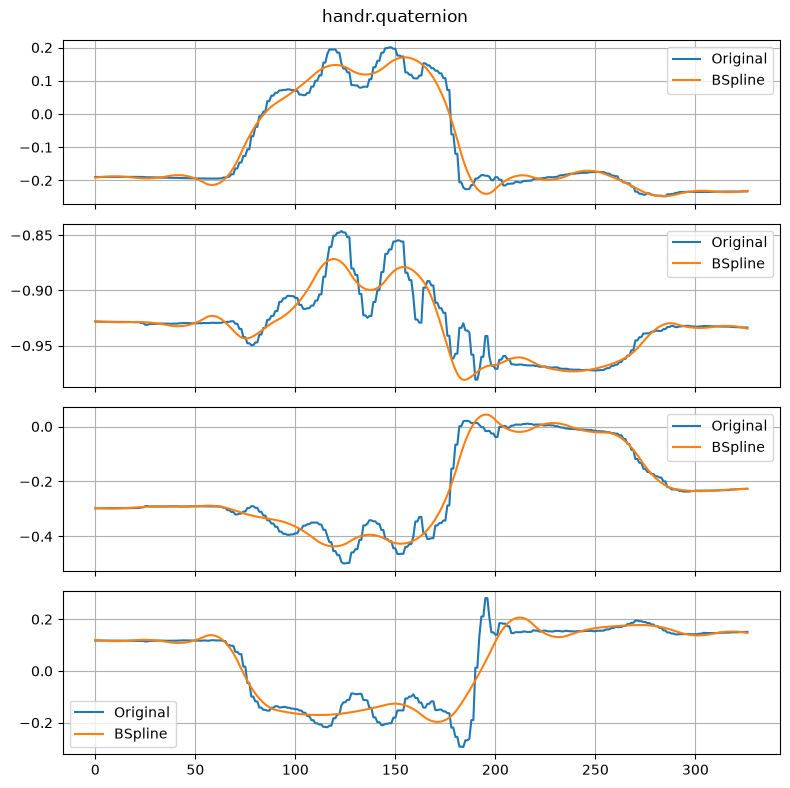

In [14]:
fig, axs = plt.subplots(4, 1, figsize=(8,8), sharex=True)

joint_idx = get_joint_idx(original_clip, "handr")
original_quats = AntipodalPreprocessor().process(original_clip["animationClip"]["tracks"][joint_idx])
original_quats = np.reshape(original_quats["values"], shape=(-1, 4))
bspline_quats = np.reshape(recon_bspline_clip["animationClip"]["tracks"][joint_idx]["values"], shape=(-1, 4))

for i, ax in enumerate(axs):
    ax.plot(original_quats[:, i], label="Original")
    ax.plot(bspline_quats[:, i], label="BSpline")
    ax.grid()
    ax.legend()

fig.suptitle(original_clip["animationClip"]["tracks"][joint_idx]["name"])
fig.tight_layout()
plt.show()

---
## Compression Performance

In [15]:
# original_ram_size  = asizeof.asizeof(original_clip) / 1024
# raw_base64_ram_size  = asizeof.asizeof(raw_base64_clip) / 1024
# quantize_ram_size  = asizeof.asizeof(quantize_clip) / 1024
# bspline_ram_size  = asizeof.asizeof(bspline_clip) / 1024

original_disk_size = os.path.getsize(original_path) / 1024
raw_base64_disk_size = os.path.getsize(raw_base64_path) / 1024
quantize_disk_size = os.path.getsize(quantize_path) / 1024
bspline_disk_size = os.path.getsize(bspline_path) / 1024

In [16]:
save_raw_base64_original = 100 - 100 * raw_base64_disk_size / original_disk_size
save_quantize_original   = 100 - 100 * quantize_disk_size / original_disk_size
save_quantize_raw_base64 = 100 - 100 * quantize_disk_size / raw_base64_disk_size
save_bspline_original    = 100 - 100 * bspline_disk_size / original_disk_size
save_bspline_raw_base64  = 100 - 100 * bspline_disk_size / raw_base64_disk_size

print("=== Compression Performace (On-Disk) ===")
print(f"Original  : {original_disk_size:,.0f} KB")
print(f"RawBase64 : {raw_base64_disk_size:,.0f} KB — {save_raw_base64_original:,.2f}% saved from Original")
print(f"Quantize  : {quantize_disk_size:,.0f} KB — {save_quantize_original:,.2f}% saved from Original — {save_quantize_raw_base64:,.2f}% saved from RawBase64")
print(f"Bspline   : {bspline_disk_size:,.0f} KB — {save_bspline_original:,.2f}% saved from Original — {save_bspline_raw_base64:,.2f}% saved from RawBase64")

=== Compression Performace (On-Disk) ===
Original  : 16,064 KB
RawBase64 : 4,256 KB — 73.51% saved from Original
Quantize  : 854 KB — 94.68% saved from Original — 79.92% saved from RawBase64
Bspline   : 647 KB — 95.97% saved from Original — 84.79% saved from RawBase64


In [17]:
# save_raw_base64_original = 100 - 100 * raw_base64_ram_size / original_ram_size
# save_quantize_original   = 100 - 100 * quantize_ram_size / original_ram_size
# save_quantize_raw_base64 = 100 - 100 * quantize_ram_size / raw_base64_ram_size
# save_bspline_original    = 100 - 100 * bspline_ram_size / original_ram_size
# save_bspline_raw_base64  = 100 - 100 * bspline_ram_size / raw_base64_ram_size

# print("=== Compression Performace (In-RAM) ===")
# print(f"Original  : {original_ram_size:,.0f} KB")
# print(f"RawBase64 : {raw_base64_ram_size:,.0f} KB — {save_raw_base64_original:,.2f}% saved from Original")
# print(f"Quantize  : {quantize_ram_size:,.0f} KB — {save_quantize_original:,.2f}% saved from Original — {save_quantize_raw_base64:,.2f}% saved from RawBase64")
# print(f"Bspline   : {bspline_ram_size:,.0f} KB — {save_bspline_original:,.2f}% saved from Original — {save_bspline_raw_base64:,.2f}% saved from RawBase64")